In [1]:
from opendrift.models.openoil import OpenOil
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# model.py sits next to this notebook; import the pipeline functions instead
# of redefining them inline.
sys.path.insert(0, str(Path.cwd()))
from model import trace_origin, get_origin_estimate, get_current_wind

print("Opendrift ready")


Opendrift ready


11:30:19 WARNING opendrift:2574: Plotting fast. This will make your plots less accurate.


Forward Simulation Complete


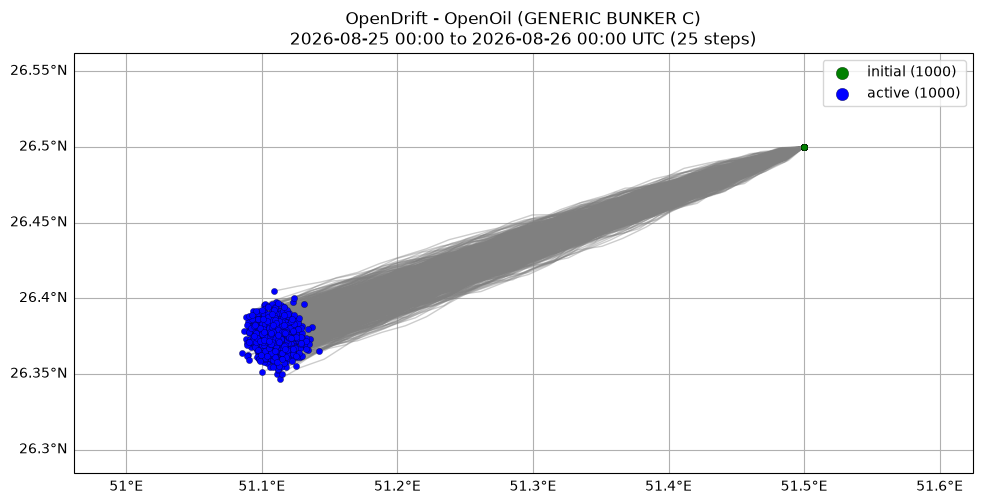

(<GeoAxes: title={'center': 'OpenDrift - OpenOil (GENERIC BUNKER C)\n2026-08-25 00:00 to 2026-08-26 00:00 UTC (25 steps)'}>,
 <Figure size 1100x514.523 with 1 Axes>)

In [2]:
# Forward simulation
o_forward = OpenOil(loglevel = 30)

o_forward.set_config('environment:fallback:x_wind', -5)
o_forward.set_config('environment:fallback:y_wind', -2)
o_forward.set_config('environment:fallback:x_sea_water_velocity', -0.3)
o_forward.set_config('environment:fallback:y_sea_water_velocity', -0.1)

detection_time = datetime(2026, 8, 25, 0, 0) # example: spill detecton time
detection_lon, detection_lat = 51.5, 26.5  # central Persian Gulf, open water

o_forward.seed_elements(lon=detection_lon, lat=detection_lat, number = 1000, time = detection_time, oil_type = "GENERIC BUNKER C")
o_forward.run(duration = timedelta(hours=24), time_step=3600)
print("Forward Simulation Complete")
o_forward.plot(fast = True)

11:30:23 WARNING opendrift:2574: Plotting fast. This will make your plots less accurate.


Backward Simulation Complete


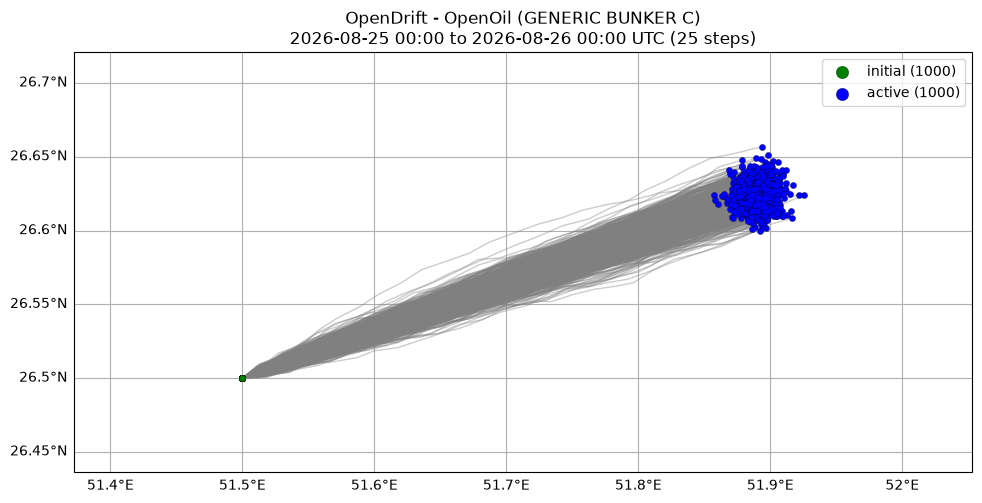

(<GeoAxes: title={'center': 'OpenDrift - OpenOil (GENERIC BUNKER C)\n2026-08-25 00:00 to 2026-08-26 00:00 UTC (25 steps)'}>,
 <Figure size 1100x513.976 with 1 Axes>)

In [3]:
# Backward Simulation
o_backward = OpenOil(loglevel=30)

o_backward.set_config('environment:fallback:x_wind', 5)
o_backward.set_config('environment:fallback:y_wind', 2)
o_backward.set_config('environment:fallback:x_sea_water_velocity', 0.3)
o_backward.set_config('environment:fallback:y_sea_water_velocity', 0.1)

o_backward.seed_elements(lon = detection_lon, lat = detection_lat, number = 1000, time=detection_time, oil_type='GENERIC BUNKER C')
o_backward.run(duration=timedelta(hours=24), time_step=3600)
print("Backward Simulation Complete")
o_backward.plot(fast=True)

In [4]:
# Final Particle Positions
final_lons = o_backward.result.lon.isel(time=-1).values
final_lats = o_backward.result.lat.isel(time=-1).values

estimated_origin_lon = np.nanmean(final_lons)
estimated_origin_lat = np.nanmean(final_lats)

print(f"Estimated origin: {estimated_origin_lon:.4f} E, {estimated_origin_lat:.4f} N")
print(f"Estimated origin time: {detection_time - timedelta(hours=24)}")

Estimated origin: 51.8901 E, 26.6250 N
Estimated origin time: 2026-08-24 00:00:00


In [5]:
import os
import copernicusmarine

output_file = "demo_currents_persian_gulf.nc"  # new filename

if not os.path.exists(output_file):
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",
        variables=["uo", "vo"],
        minimum_longitude=48, maximum_longitude=57,
        minimum_latitude=24, maximum_latitude=30,
        minimum_depth=0,
        maximum_depth=1,
        start_datetime="2026-08-26T00:00:00",
        end_datetime="2026-08-29T00:00:00",
        output_filename=output_file,
    )
    print("Downloaded fresh Persian Gulf current data")
else:
    print("Using cached local file — skipping download")

Using cached local file — skipping download


In [6]:
# get_current_wind() is defined in model.py (imported in the first cell).
# NOTE the (lat, lon) argument order - the demo point is 26.5 N, 51.5 E.
wind_u, wind_v = get_current_wind(26.5, 51.5)
print(f"Wind u/v: {wind_u:.2f}, {wind_v:.2f}")


Wind u/v: 0.91, -2.66


In [7]:
from opendrift.readers import reader_netCDF_CF_generic

reader_currents = reader_netCDF_CF_generic.Reader("demo_currents_persian_gulf.nc")
print(reader_currents)  # check the coverage/time range

Reader: demo_currents_persian_gulf.nc
Reader type: opendrift.readers.reader_netCDF_CF_generic
Projection: 
  +proj=latlong
Coverage: [degrees]
  xmin: 48.000000   xmax: 57.000000   step: 0.0833435   numx: 108
  ymin: 24.000000   ymax: 30.000000   step: 0.0833359   numy: 72
  Corners (lon, lat):
    ( 48.00,  30.00)  ( 57.00,  30.00)
    ( 48.00,  24.00)  ( 57.00,  24.00)
Vertical levels [m]: 
  [-0.494025]
Available time range:
  start: 2026-08-26 00:00:00   end: 2026-08-29 00:00:00   step: 1:00:00
    73 times (0 missing)
Variables:
  eastward_sea_water_velocity
  northward_sea_water_velocity
  x_sea_water_velocity
  y_sea_water_velocity
  sea_water_speed - derived from ['x_sea_water_velocity', 'y_sea_water_velocity']



11:30:27 WARNING opendrift:2574: Plotting fast. This will make your plots less accurate.


Backward trace with real data complete


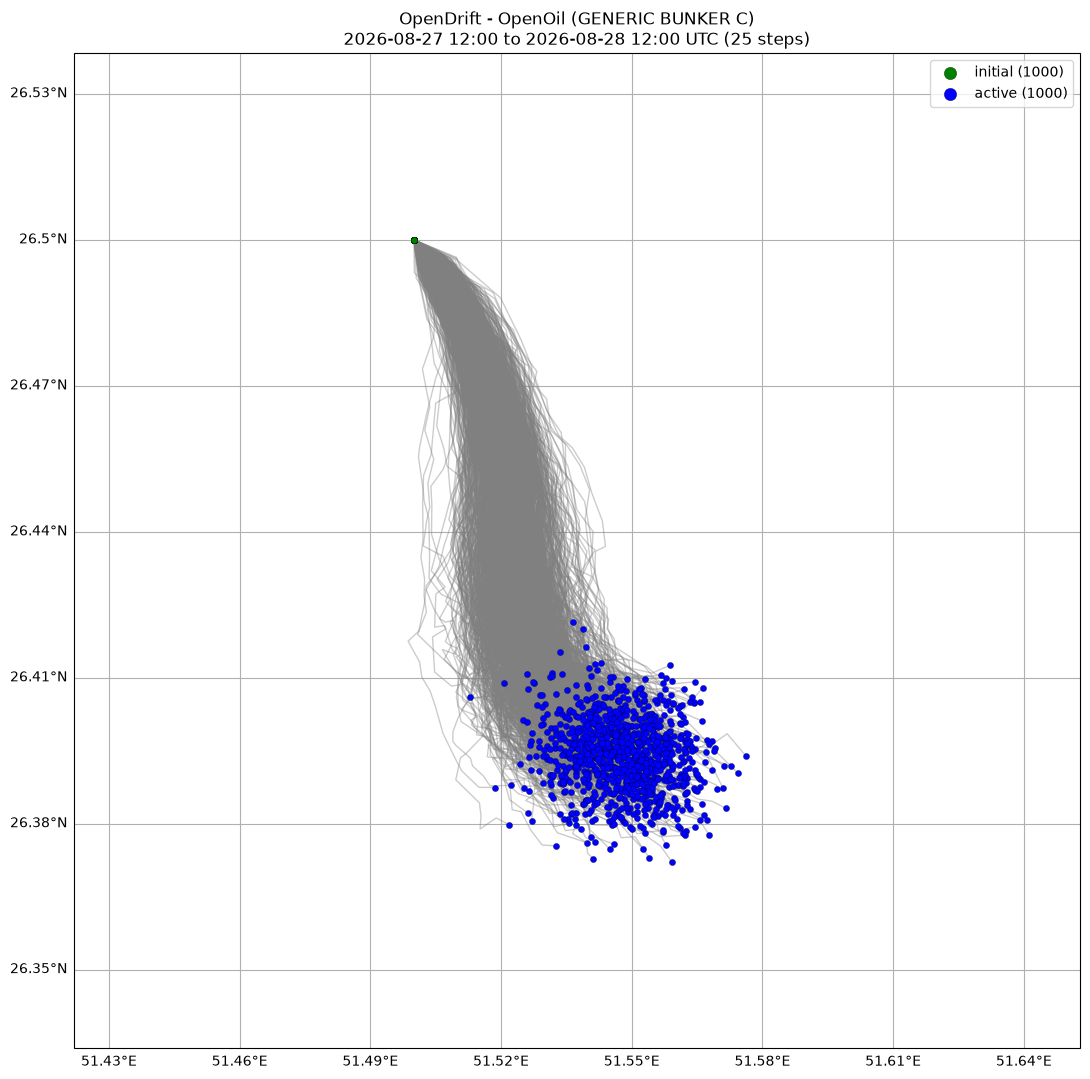

(<GeoAxes: title={'center': 'OpenDrift - OpenOil (GENERIC BUNKER C)\n2026-08-27 12:00 to 2026-08-28 12:00 UTC (25 steps)'}>,
 <Figure size 1100x1088.06 with 1 Axes>)

In [8]:
detection_time = datetime(2026, 8, 27, 12, 0, 0)  # within your data's 08-26 to 08-29 range
detection_lon, detection_lat = 51.5, 26.5  # central Persian Gulf, open water


o_backward = OpenOil(loglevel=30)
o_backward.add_reader([reader_currents])
o_backward.set_config('environment:fallback:x_wind', wind_u)
o_backward.set_config('environment:fallback:y_wind', wind_v)

o_backward.seed_elements(lon=detection_lon, lat=detection_lat, number=1000, time=detection_time, oil_type='GENERIC BUNKER C')
o_backward.run(duration=timedelta(hours=24), time_step=3600)
print("Backward trace with real data complete")
o_backward.plot(fast=True)

In [9]:
final_lons = o_backward.result.lon.isel(time=-1).values
final_lats = o_backward.result.lat.isel(time=-1).values

estimated_origin_lon = np.nanmean(final_lons)
estimated_origin_lat = np.nanmean(final_lats)
estimated_origin_time = detection_time - timedelta(hours=24)

print(f"Estimated origin: {estimated_origin_lon:.4f}°E, {estimated_origin_lat:.4f}°N at {estimated_origin_time}")

Estimated origin: 51.5477°E, 26.3942°N at 2026-08-26 12:00:00


In [10]:
# get_origin_estimate() is defined in model.py (imported in the first cell).
lon, lat, time, stranded_early = get_origin_estimate(o_backward, detection_time)
print(f"Origin: {lon:.4f}, {lat:.4f} at {time} (stranded early: {stranded_early})")


Origin: 51.5477, 26.3942 at 2026-08-26 12:00:00 (stranded early: False)


In [11]:
# trace_origin() is defined in model.py (imported in the first cell) - the
# same function the backend calls through drift_trace.model.


In [12]:
import json

result = trace_origin(
    51.5, 26.5,
    datetime(2026, 8, 27, 12, 0, 0),
    wind_u=wind_u,
    wind_v=wind_v,
    currents_file="demo_currents_persian_gulf.nc"
)

# Results are consolidated under ml/results/.
with open("../results/stage2_results.json", "w") as f:
    json.dump({
        "detection_point": [51.5, 26.5],
        "detection_time": "2026-08-27T12:00:00",
        "estimated_origin_lon": float(result["estimated_origin_lon"]),
        "estimated_origin_lat": float(result["estimated_origin_lat"]),
        "estimated_origin_time": str(result["estimated_origin_time"]),
        "origin_window_start": str(result["origin_window_start"]),
        "origin_window_end": str(result["origin_window_end"]),
        "stranded_early": bool(result["stranded_early"]),
        "known_limitations": "Coordinate extraction from real satellite imagery not yet implemented (demo uses manually-specified coordinates); accuracy bounded by wind/current data resolution; near-real-time current data only covers a rolling recent window; demo uses a manually-specified detection time (not derived from the SAR image itself, which has no embedded timestamp in this dataset) to demonstrate Stage 2's use of real, current environmental data.",
    }, f, indent=2)

print("Stage 2 results saved")
print(json.dumps(result, default=str, indent=2))


Stage 2 results saved
{
  "estimated_origin_lon": "51.54772",
  "estimated_origin_lat": "26.394156",
  "estimated_origin_time": "2026-08-26 12:00:00",
  "origin_window_start": "2026-08-26 09:00:00",
  "origin_window_end": "2026-08-26 15:00:00",
  "stranded_early": false
}
